# Elo Modeling

Tujuan : 

Notebook ini bertujuan mengevaluasi pengaruh penambahan **Elo Rating** terhadap performa model dalam memprediksi hasil pertandingan sepak bola internasional.

Berbeda dengan *Historical Modeling* yang hanya memanfaatkan fitur dasar dan statistik historis, tahap ini menambahkan representasi kekuatan relatif tim melalui **Elo Rating** yang dihitung secara kronologis menggunakan seluruh riwayat pertandingan.

Eksperimen tetap menggunakan algoritma dan strategi pemodelan yang sama, yaitu **Logistic Regression** dan **Random Forest**, sehingga setiap perubahan performa dapat diatribusikan pada informasi tambahan yang diberikan oleh fitur Elo, bukan karena perubahan model atau proses *preprocessing*.

Hasil evaluasi pada notebook ini akan dibandingkan dengan eksperimen sebelumnya untuk mengetahui apakah Elo Rating mampu meningkatkan kualitas prediksi secara terukur.

## 1. Load Elo Dataset

Dataset yang digunakan pada tahap ini merupakan hasil dari notebook **Elo Rating Engine**. Dataset tersebut telah memuat seluruh fitur dasar (*baseline features*), fitur historis (*historical features*), serta fitur **Elo Rating** yang dibangun secara kronologis.
Sebelum memulai proses pemodelan, kita akan memuat dataset dan melakukan pengecekan singkat untuk memastikan struktur data sesuai dengan yang diharapkan.

In [14]:
import pandas as pd

In [15]:
elo_df = pd.read_csv("../data/processed/elo_features.csv")

In [16]:
elo_df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,home_last5_winrate,away_last5_winrate,home_last10_winrate,...,away_avg_goals_scored,home_avg_goals_conceded,away_avg_goals_conceded,home_goal_difference_form,away_goal_difference_form,match_result,home_elo_before,away_elo_before,home_elo_after,away_elo_after
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,D,1500.000000,1500.000000,1500.000000,1500.000000
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,False,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,H,1500.000000,1500.000000,1510.000000,1490.000000
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,False,0.000000,0.500000,0.000000,...,2.000000,2.000000,1.000000,-1.000000,1.000000,H,1490.000000,1510.000000,1500.575011,1499.424989
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,False,0.333333,0.333333,0.333333,...,1.333333,1.333333,1.666667,0.333333,-0.333333,D,1499.424989,1500.575011,1499.458089,1500.541911
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,False,0.250000,0.250000,0.250000,...,1.750000,1.750000,1.500000,-0.250000,0.250000,H,1500.541911,1499.458089,1510.510716,1489.489284


In [17]:
elo_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49433 entries, 0 to 49432
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       49433 non-null  str    
 1   home_team                  49433 non-null  str    
 2   away_team                  49433 non-null  str    
 3   home_score                 49433 non-null  float64
 4   away_score                 49433 non-null  float64
 5   tournament                 49433 non-null  str    
 6   neutral                    49433 non-null  bool   
 7   home_last5_winrate         49292 non-null  float64
 8   away_last5_winrate         49238 non-null  float64
 9   home_last10_winrate        49292 non-null  float64
 10  away_last10_winrate        49238 non-null  float64
 11  home_avg_goals_scored      49292 non-null  float64
 12  away_avg_goals_scored      49238 non-null  float64
 13  home_avg_goals_conceded    49292 non-null  float64
 14  a

Dataset berhasil dimuat dan telah memuat seluruh fitur yang dibutuhkan untuk proses pemodelan. Selain fitur dasar dan fitur historis, dataset kini juga memiliki empat kolom Elo Rating, yaitu:

- `home_elo_before`
- `away_elo_before`
- `home_elo_after`
- `away_elo_after`

Pada tahap pemodelan, hanya **Elo sebelum pertandingan** (`home_elo_before` dan `away_elo_before`) yang akan digunakan sebagai fitur prediktif karena nilai tersebut memang tersedia sebelum pertandingan dimulai. Sebaliknya, `home_elo_after` dan `away_elo_after` merupakan hasil pembaruan setelah pertandingan selesai sehingga tidak digunakan sebagai input model untuk menghindari *future data leakage*.

## 3. Feature & Target Separation

Pada tahap ini, kita akan memisahkan **fitur (X)** dan **target (y)** yang akan digunakan pada proses pemodelan.
Variabel target tetap menggunakan `match_result` yang dibentuk berdasarkan hasil akhir pertandingan. Sementara itu, fitur yang digunakan merupakan kombinasi dari:
- **Baseline Features**
- **Historical Features**
- **Elo Rating Features**
Seluruh fitur dipilih berdasarkan informasi yang memang tersedia **sebelum pertandingan dimulai**, sehingga proses pemodelan tetap terhindar dari *future data leakage*.

In [18]:
# MEMBENTUK TARGET
def get_match_result(row):
    if row["home_score"] > row["away_score"]:
        return "H"
    elif row["home_score"] < row["away_score"]:
        return "A"
    else:
        return "D"

elo_df["match_result"] = elo_df.apply(get_match_result, axis=1)

In [19]:
# MENENTUKAN FEATURE
feature_columns = [

    # Baseline Features
    "home_team",
    "away_team",
    "tournament",
    "neutral",

    # Historical Features
    "home_last5_winrate",
    "away_last5_winrate",
    "home_last10_winrate",
    "away_last10_winrate",
    "home_avg_goals_scored",
    "away_avg_goals_scored",
    "home_avg_goals_conceded",
    "away_avg_goals_conceded",
    "home_goal_difference_form",
    "away_goal_difference_form",

    # Elo Features
    "home_elo_before",
    "away_elo_before"
]

In [20]:
# PISAHKAN X DAN Y
X = elo_df[feature_columns]

y = elo_df["match_result"]

In [21]:
# CEK BENTUK
print(f"Feature Shape : {X.shape}")
print(f"Target Shape  : {y.shape}")

Feature Shape : (49433, 16)
Target Shape  : (49433,)


## 4. Time-based Train-Test Split

Pembagian data dilakukan menggunakan **time-based split**, yaitu berdasarkan urutan kronologis pertandingan.

Pendekatan ini dipilih agar proses pelatihan dan evaluasi menyerupai kondisi di dunia nyata, di mana model hanya memanfaatkan data pertandingan yang telah terjadi untuk memprediksi pertandingan pada masa berikutnya. Selain itu, penggunaan *time-based split* juga membantu mencegah *future data leakage* yang dapat terjadi apabila data dibagi secara acak (*random split*).

In [22]:
# SPLIT DATA
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [23]:
# CEK
print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

print()

print(f"Training Target   : {y_train.shape}")
print(f"Testing Target    : {y_test.shape}")

Training Features : (39546, 16)
Testing Features  : (9887, 16)

Training Target   : (39546,)
Testing Target    : (9887,)


Dataset berhasil dibagi menggunakan **time-based split** dengan proporsi sekitar **80% data pelatihan** dan **20% data pengujian**. Strategi pembagian ini dipertahankan agar konsisten dengan eksperimen Baseline Modeling maupun Historical Modeling, sehingga hasil evaluasi pada notebook ini dapat dibandingkan secara langsung dan adil.

## 5. Elo Modeling

Tahap ini membangun model klasifikasi menggunakan kombinasi **baseline features**, **historical features**, dan **Elo Rating**.

Sama seperti eksperimen sebelumnya, proses *preprocessing* dilakukan menggunakan **Pipeline** sehingga seluruh transformasi hanya dipelajari dari data pelatihan. Pendekatan ini membantu menjaga konsistensi eksperimen sekaligus mencegah *data leakage*.

### 5.1 Feature Types

In [24]:
categorical_features = [
    "home_team",
    "away_team",
    "tournament",
    "neutral"
]

numerical_features = [
    "home_last5_winrate",
    "away_last5_winrate",
    "home_last10_winrate",
    "away_last10_winrate",
    "home_avg_goals_scored",
    "away_avg_goals_scored",
    "home_avg_goals_conceded",
    "away_avg_goals_conceded",
    "home_goal_difference_form",
    "away_goal_difference_form",

    "home_elo_before",
    "away_elo_before"
]

Fitur yang digunakan terdiri atas dua kelompok utama, yaitu fitur kategorikal dan fitur numerik. Seluruh fitur historis dan Elo Rating termasuk ke dalam fitur numerik sehingga tidak memerlukan proses *encoding*. Sebaliknya, fitur identitas tim dan informasi pertandingan tetap diperlakukan sebagai fitur kategorikal yang akan di-*encode* melalui *Pipeline*.

### 5.2 Modeling Pipeline

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            SimpleImputer(
                strategy="constant",
                fill_value=0
            ),
            numerical_features
        )
    ]
)

Pipeline *preprocessing* tetap mempertahankan struktur yang sama dengan notebook Historical Modeling. Fitur kategorikal diubah menggunakan **OneHotEncoder**, sedangkan fitur numerik diproses menggunakan **SimpleImputer** untuk menangani nilai *NaN* akibat *cold start problem* pada fitur historis.

Dengan mempertahankan pipeline yang sama, satu-satunya perubahan pada eksperimen ini adalah penambahan fitur Elo Rating. Hal ini memastikan bahwa setiap perubahan performa model dapat diatribusikan pada kualitas informasi yang diberikan oleh fitur Elo, bukan karena perubahan strategi *preprocessing*.

### 5.3 Logistic Regression
Model pertama yang digunakan adalah **Logistic Regression** sebagai model baseline linear. Sama seperti eksperimen sebelumnya, model dibangun menggunakan **Pipeline** yang menggabungkan proses *preprocessing* dan algoritma klasifikasi menjadi satu alur kerja yang konsisten. Dengan pendekatan ini, seluruh proses transformasi data hanya dipelajari dari data pelatihan sehingga tetap terhindar dari *data leakage*.

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [29]:
logistic_pipeline.fit(X_train, y_train)

C:\Users\Asus\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [30]:
y_pred_lr = logistic_pipeline.predict(X_test)

Model Logistic Regression berhasil dilatih menggunakan kombinasi fitur dasar, fitur historis, dan Elo Rating. Hasil prediksi pada data pengujian akan dievaluasi pada tahap berikutnya untuk mengetahui sejauh mana penambahan informasi Elo mampu meningkatkan kualitas prediksi dibandingkan eksperimen sebelumnya.

### 5.4 Random Forest

Sebagai pembanding terhadap model linear, digunakan **Random Forest Classifier** yang mampu mempelajari hubungan non-linear antar fitur. Sama seperti Logistic Regression, model dibangun menggunakan Pipeline yang identik sehingga perbedaan performa nantinya hanya berasal dari karakteristik algoritma, bukan dari proses *preprocessing*.

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

In [33]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [34]:
y_pred_rf = random_forest_pipeline.predict(X_test)

Model Random Forest berhasil dilatih menggunakan konfigurasi yang sama seperti eksperimen sebelumnya. Dengan demikian, kedua model kini siap dievaluasi untuk mengetahui apakah penambahan fitur Elo Rating memberikan peningkatan performa prediksi yang konsisten.

## 6. Model Evaluation

Tahap ini bertujuan mengevaluasi performa kedua model menggunakan beberapa metrik klasifikasi serta membandingkan hasil eksperimen Elo Modeling dengan eksperimen sebelumnya.

Evaluasi dilakukan menggunakan **Accuracy**, **Precision**, **Recall**, dan **F1 Score**, disertai *classification report* serta *confusion matrix* untuk melihat kemampuan model pada masing-masing kelas hasil pertandingan. Selain itu, hasil Elo Modeling juga akan dibandingkan secara langsung dengan Historical Modeling guna mengetahui apakah penambahan fitur Elo Rating benar-benar memberikan peningkatan performa prediksi.

### 6.1 Logistic Regression

Logistic Regression dievaluasi menggunakan data pengujian untuk mengetahui kemampuan model dalam memprediksi hasil pertandingan setelah penambahan fitur Elo Rating. Nilai evaluasi pada bagian ini akan menjadi dasar perbandingan dengan eksperimen Historical Modeling.

In [35]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           A       0.58      0.59      0.58      2870
           D       0.45      0.01      0.01      2304
           H       0.60      0.88      0.72      4713

    accuracy                           0.59      9887
   macro avg       0.54      0.49      0.44      9887
weighted avg       0.56      0.59      0.51      9887



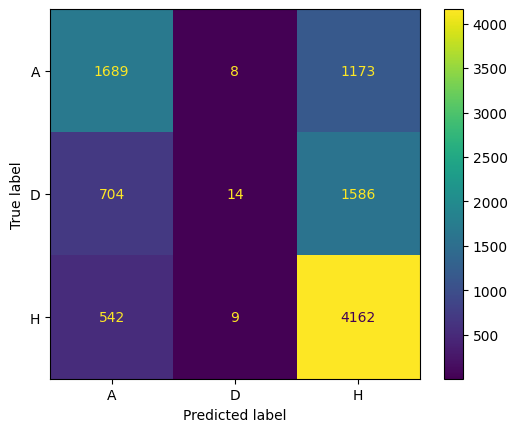

In [36]:
# CONFUSION MATRIX

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
);

In [37]:
# METRICS

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

Accuracy  : 0.5932
Precision : 0.5589
Recall    : 0.5932
F1 Score  : 0.5128


### 6.2 Random Forest

Hasil evaluasi Random Forest digunakan sebagai pembanding terhadap Logistic Regression sekaligus untuk mengukur seberapa besar kontribusi fitur Elo Rating terhadap model non-linear.

In [38]:
# CLASSIFICATION REPORT
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           A       0.57      0.51      0.54      2870
           D       0.35      0.04      0.08      2304
           H       0.59      0.88      0.70      4713

    accuracy                           0.58      9887
   macro avg       0.50      0.48      0.44      9887
weighted avg       0.53      0.58      0.51      9887



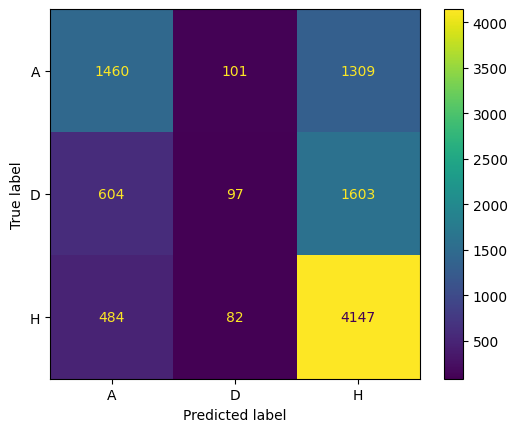

In [39]:
# CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
);

In [40]:
# METRICS
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Accuracy  : 0.5769
Precision : 0.5271
Recall    : 0.5769
F1 Score  : 0.5098


### 6.3 Elo Model Comparison

Tabel perbandingan menunjukkan performa kedua model pada eksperimen Elo Modeling. Model dengan nilai evaluasi terbaik akan dipilih sebagai representasi terbaik pada tahap ini sebelum dibandingkan dengan eksperimen Historical Modeling.

In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.593203,0.558947,0.593203,0.512776
1,Random Forest,0.576919,0.527102,0.576919,0.509791


### 6.4 Historical vs Elo Comparison

In [42]:
historical_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Historical Accuracy": [
        0.5805,
        0.5467
    ],
    "Elo Accuracy": [
        lr_accuracy,
        rf_accuracy
    ]
})

historical_comparison["Improvement"] = (
    historical_comparison["Elo Accuracy"]
    - historical_comparison["Historical Accuracy"]
)

historical_comparison

,Model,Historical Accuracy,Elo Accuracy,Improvement
0,Logistic Regression,0.5805,0.593203,0.012703
1,Random Forest,0.5467,0.576919,0.030219


### 6.5 Insight
Penambahan fitur Elo Rating berhasil meningkatkan performa prediksi pada kedua algoritma yang diuji. Logistic Regression kembali menjadi model terbaik dengan akurasi 59.32%, meningkat dari 58.05% pada Historical Modeling. Sementara itu, Random Forest menunjukkan peningkatan yang lebih besar, dari 54.67% menjadi 57.69%. Temuan ini memperkuat hipotesis bahwa representasi kekuatan tim melalui Elo Rating memberikan informasi prediktif yang melengkapi statistik historis.

Meskipun demikian, kedua model masih mengalami kesulitan dalam memprediksi hasil Draw, yang ditunjukkan oleh nilai recall yang sangat rendah pada kelas tersebut. Hal ini mengindikasikan bahwa kombinasi statistik historis dan Elo Rating belum sepenuhnya mampu merepresentasikan kondisi pertandingan yang berakhir imbang. Oleh karena itu, tahap berikutnya akan berfokus pada penggunaan algoritma yang lebih kuat, seperti XGBoost dan LightGBM, untuk mengeksplorasi apakah hubungan yang lebih kompleks antar fitur dapat meningkatkan kemampuan model dalam menangkap pola tersebut.

## 7. Save Model

In [43]:
import joblib


# SAVE MODEL
joblib.dump(
    logistic_pipeline,
    "../models/logistic_regression_elo.pkl"
)

joblib.dump(
    random_forest_pipeline,
    "../models/random_forest_elo.pkl"
)

['../models/random_forest_elo.pkl']

Kedua model berhasil disimpan dalam bentuk Pipeline menggunakan `joblib`. Karena Pipeline telah mencakup seluruh proses preprocessing dan model klasifikasi, file yang disimpan dapat langsung digunakan kembali untuk proses prediksi tanpa perlu membangun ulang encoder maupun preprocessing secara terpisah.

In [44]:
# SAVE METRICS
metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ]
})

metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.593203,0.558947,0.593203,0.512776
1,Random Forest,0.576919,0.527102,0.576919,0.509791


In [45]:
# SAVE METRICS
metrics.to_csv(
    "../reports/elo_metrics.csv",
    index=False
)

Seluruh metrik evaluasi disimpan sebagai `elo_metrics.csv` agar dapat digunakan sebagai dokumentasi hasil eksperimen sekaligus mempermudah proses benchmarking dengan notebook sebelumnya maupun eksperimen lanjutan.